# Proyecto de Minería de Datos - Inicio CRISP-DM

Este notebook inicia el proceso CRISP-DM para el dataset ubicado en `archive`, consolidando **todos los CSV en un único DataFrame** para comenzar la fase de comprensión y preparación de datos.

**Nota:** no se ejecuta automáticamente; está listo para que continúes.

## Fases CRISP-DM (alcance de este notebook)
- 1) Comprensión del negocio (documentar objetivo/problema).
- 2) Comprensión de los datos (carga unificada + EDA inicial).
- 3) Preparación de los datos (siguientes pasos).
- 4) Modelado (pendiente).
- 5) Evaluación (pendiente).
- 6) Despliegue (no requerido, pero se dejará reflexión al final del proyecto).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

In [2]:
# Ruta del dataset
DATA_DIR = Path("/home/diegono/VII/D.S./FIN/archive")
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"CSV encontrados: {len(csv_files)}")
for f in csv_files:
    print("-", f.name)

CSV encontrados: 5
- games.csv
- genre_summary.csv
- platform_summary.csv
- publisher_summary.csv
- yearly_trends.csv


In [3]:
def read_csv_flexible(file_path: Path) -> pd.DataFrame:
    """Intenta cargar CSV con separadores comunes para evitar fallos de lectura."""
    separators = [",", ";", "\t", "|"]
    for sep in separators:
        try:
            df = pd.read_csv(file_path, sep=sep, engine="python")
            if df.shape[1] > 1:
                return df
        except Exception:
            continue
    return pd.read_csv(file_path)

# raw_tables mantiene cada CSV por separado, útil para análisis posteriores
raw_tables = {}

for file_path in csv_files:
    table_name = file_path.stem
    df_temp = read_csv_flexible(file_path)
    raw_tables[table_name] = df_temp.copy()

print(f"Tablas cargadas en raw_tables: {list(raw_tables.keys())}")

# Construir DataFrame unificado mergeando correctamente por IDs
# Tabla principal: games (con game_id)
df_all = raw_tables["games"].copy()

# Merge con genre_summary por género
if "genre_summary" in raw_tables:
    genre_cols = raw_tables["genre_summary"].columns.tolist()
    genre_cols = [f"genre_{col}" if col != "genre" else col for col in genre_cols]
    df_genre = raw_tables["genre_summary"].copy()
    df_genre.columns = genre_cols
    df_all = df_all.merge(df_genre, on="genre", how="left")
    print(f"✓ Merged genre_summary: +{len(genre_cols)-1} columnas")

# Merge con platform_summary por plataforma
if "platform_summary" in raw_tables:
    platform_cols = raw_tables["platform_summary"].columns.tolist()
    platform_cols = [f"platform_{col}" if col != "platform" else col for col in platform_cols]
    df_platform = raw_tables["platform_summary"].copy()
    df_platform.columns = platform_cols
    df_all = df_all.merge(df_platform, on="platform", how="left")
    print(f"✓ Merged platform_summary: +{len(platform_cols)-1} columnas")

# Merge con publisher_summary por publicador
if "publisher_summary" in raw_tables:
    pub_cols = raw_tables["publisher_summary"].columns.tolist()
    pub_cols = [f"pub_{col}" if col != "publisher" else col for col in pub_cols]
    df_pub = raw_tables["publisher_summary"].copy()
    df_pub.columns = pub_cols
    df_all = df_all.merge(df_pub, on="publisher", how="left")
    print(f"✓ Merged publisher_summary: +{len(pub_cols)-1} columnas")

# Merge con yearly_trends por año
if "yearly_trends" in raw_tables:
    year_cols = raw_tables["yearly_trends"].columns.tolist()
    year_cols = [f"year_{col}" if col != "year" else col for col in year_cols]
    df_year = raw_tables["yearly_trends"].copy()
    df_year.columns = year_cols
    df_all = df_all.merge(df_year, on="year", how="left")
    print(f"✓ Merged yearly_trends: +{len(year_cols)-1} columnas")

Tablas cargadas en raw_tables: ['games', 'genre_summary', 'platform_summary', 'publisher_summary', 'yearly_trends']
✓ Merged genre_summary: +10 columnas
✓ Merged platform_summary: +8 columnas
✓ Merged publisher_summary: +8 columnas
✓ Merged yearly_trends: +10 columnas


In [4]:
print("\n" + "="*60)
print("RESULTADO: DataFrame unificado (mergeado correctamente)")
print("="*60)
print(f"Forma: {df_all.shape}")
print(f"Número de columnas: {len(df_all.columns)}")
print(f"\nPrimeras filas:")
display(df_all.head())

print(f"\nMuestra aleatoria:")
display(df_all.sample(min(5, len(df_all)), random_state=42))


RESULTADO: DataFrame unificado (mergeado correctamente)
Forma: (50000, 71)
Número de columnas: 71

Primeras filas:


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,genre_titles,genre_total_sales_m,genre_avg_sales_m,genre_avg_metacritic,genre_avg_user_score,genre_pct_goty_nominated,genre_avg_htlb_main,genre_pct_online,genre_pct_dlc,genre_pct_microtransactions,platform_platform_type,platform_platform_maker,platform_titles,platform_total_sales_m,platform_avg_metacritic,platform_avg_user_score,platform_top_genre,platform_avg_launch_price,pub_publisher_tier,pub_publisher_region,pub_titles,pub_total_sales_m,pub_avg_metacritic,pub_goty_wins,pub_avg_revenue_m,pub_pct_sequels,year_titles_released,year_total_sales_m,year_avg_metacritic,year_avg_user_score,year_pct_online,year_pct_microtransactions,year_pct_dlc,year_avg_launch_price,year_goty_games,year_avg_htlb
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,M,69,6.7,34,1172,10.01,8.35,2.58,3.46,24.40,575.88,49.99,1,1,1,0,0,0,0,0,0,31.8,86.1,5571,263838.83,47.36,71.24,7.14,0.02,20.02,1.00,0.62,0.49,Handheld,Nintendo,2107,26967.00,74.20,7.40,Action,34.79,AAA,Poland,1417,46506.04,75.99,8,819.63,0.40,820,17152.72,75.507,7.534,0.511,0.251,0.687,52.313,2,24.967
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,M,78,9.4,5,186,52.28,33.72,5.32,12.30,103.62,5056.51,59.99,1,0,1,1,0,0,0,0,0,13.1,55.4,460,6783.49,14.75,73.63,7.34,0.04,12.03,0.28,0.60,0.25,Console,Microsoft,991,23441.55,73.35,7.35,Action,59.45,AAA,France,1440,45677.74,75.54,5,803.36,0.41,1178,23133.98,73.337,7.333,0.491,0.260,0.680,42.237,10,26.334
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,T,76,6.6,33,363,2.90,1.48,0.75,0.91,6.04,138.60,59.99,0,0,0,0,0,0,0,0,0,9.8,20.9,1896,25942.19,13.68,69.22,6.91,0.01,11.98,0.30,0.62,0.27,PC,Various,6305,116852.54,74.17,7.42,Action,32.62,AAA,USA,1411,44643.65,75.67,20,781.40,0.41,814,17387.19,75.371,7.560,0.495,0.247,0.643,52.588,14,24.863
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,USA,AA,M,62,7.0,28,532,6.76,3.27,0.73,2.34,13.10,36.98,0.00,0,1,1,1,0,0,0,0,0,9.1,44.8,4741,169891.12,35.83,74.04,7.41,0.04,8.00,1.00,0.63,0.50,Mobile,Google,2483,177063.57,74.33,7.45,Action,2.27,AA,USA,691,5562.13,68.33,1,195.64,0.41,1412,46612.49,73.892,7.373,0.506,0.445,0.604,35.959,10,24.553
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,AO,62,5.6,58,1280,25.12,15.94,7.02,7.71,55.79,2148.24,69.99,1,1,0,1,0,0,0,0,0,150.8,322.3,949,37460.91,39.47,74.16,7.45,0.04,100.73,1.00,0.60,0.50,Console,Nintendo,878,16735.18,73.35,7.32,Action,60.63,AAA,USA,1468,45628.52,75.46,15,774.38,0.41,1225,21266.58,73.457,7.378,0.520,0.253,0.656,49.084,8,24.738



Muestra aleatoria:


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,genre_titles,genre_total_sales_m,genre_avg_sales_m,genre_avg_metacritic,genre_avg_user_score,genre_pct_goty_nominated,genre_avg_htlb_main,genre_pct_online,genre_pct_dlc,genre_pct_microtransactions,platform_platform_type,platform_platform_maker,platform_titles,platform_total_sales_m,platform_avg_metacritic,platform_avg_user_score,platform_top_genre,platform_avg_launch_price,pub_publisher_tier,pub_publisher_region,pub_titles,pub_total_sales_m,pub_avg_metacritic,pub_goty_wins,pub_avg_revenue_m,pub_pct_sequels,year_titles_released,year_total_sales_m,year_avg_metacritic,year_avg_user_score,year_pct_online,year_pct_microtransactions,year_pct_dlc,year_avg_launch_price,year_goty_games,year_avg_htlb
33553,G033554,NBA 2025,Mobile (iOS),Mobile,Apple,0,Sports,2014,Sony Interactive,Sony Interactive,Japan,AAA,M,75,7.6,25,253,219.48,99.39,153.00,65.67,537.54,1203.16,0.99,1,1,1,0,0,0,0,0,0,11.9,53.2,5571,263838.83,47.36,71.24,7.14,0.02,20.02,1.00,0.62,0.49,Mobile,Apple,2622,178785.27,74.18,7.38,Action,2.23,AAA,Japan,1552,57556.85,75.28,8,947.03,0.41,1368,34372.29,74.275,7.397,0.517,0.258,0.567,37.240,10,24.651
9427,G009428,Wipeout 3,Sega Saturn,Console,Sega,5,Racing,1994,Square Enix,Square Enix,Japan,AAA,T,85,8.1,42,160,9.83,7.20,5.98,1.59,24.60,746.41,69.99,1,0,1,0,0,0,0,0,0,14.0,58.4,3371,82745.33,24.55,74.40,7.43,0.05,15.09,0.29,0.64,0.25,Console,Sega,724,14022.96,73.85,7.40,Action,60.28,AAA,Japan,1468,56513.43,75.35,17,963.02,0.40,838,16919.36,75.579,7.550,0.499,0.251,0.696,52.037,5,26.925
199,G000200,Tales of World,NES,Console,Nintendo,3,Role-Playing,1985,Ubisoft,Toby Fox,France,AAA,T,76,6.8,63,149,1.40,0.90,0.32,0.42,3.04,108.27,39.99,0,1,0,0,0,0,0,0,0,66.2,152.1,4267,108963.88,25.54,77.46,7.76,0.09,54.96,0.29,0.62,0.24,Console,Nintendo,3045,66603.19,74.30,7.42,Action,60.14,AAA,France,1440,45677.74,75.54,5,803.36,0.41,847,18106.27,74.934,7.495,0.511,0.248,0.699,50.273,6,24.156
12447,G012448,God of Steel,PlayStation 5,Console,Sony,9,Misc,2020,InXile Entertainment,InXile Entertainment,USA,AA,E,72,7.3,23,247,1.54,0.76,0.41,0.50,3.21,119.93,69.99,0,1,1,1,0,0,0,0,0,21.1,90.0,1896,25942.19,13.68,69.22,6.91,0.01,11.98,0.30,0.62,0.27,Console,Sony,1223,37457.27,74.19,7.42,Action,59.83,AA,USA,691,5562.13,68.33,1,195.64,0.41,1415,49368.41,74.261,7.409,0.506,0.415,0.586,32.857,12,25.092
39489,G039490,Oxenfree Remastered,PlayStation 5,Console,Sony,9,Adventure,2022,Sega,Sega,Japan,AAA,T,80,8.3,50,380,13.67,8.59,5.29,1.38,28.93,960.10,49.99,0,1,1,0,0,0,0,0,0,6.6,17.6,2397,39900.59,16.65,76.59,7.66,0.07,11.83,0.33,0.61,0.24,Console,Sony,1223,37457.27,74.19,7.42,Action,59.83,AAA,Japan,1560,59199.69,75.78,16,949.42,0.42,1335,47045.16,74.065,7.440,0.500,0.423,0.585,35.107,5,25.658


In [5]:
# Resumen rápido de estructura y calidad de datos
quality_summary = pd.DataFrame({
    "dtype": df_all.dtypes.astype(str),
    "missing_count": df_all.isna().sum(),
    "missing_pct": (df_all.isna().mean() * 100).round(2),
    "n_unique": df_all.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(quality_summary.head(30))

,dtype,missing_count,missing_pct,n_unique
game_id,object,0,0.0,50000
title,object,0,0.0,1391
platform,object,0,0.0,33
platform_type,object,0,0.0,7
platform_maker,object,0,0.0,8
platform_generation,int64,0,0.0,10
genre,object,0,0.0,20
year,int64,0,0.0,42
publisher,object,0,0.0,51
developer,object,0,0.0,51


Dimensiones de cada tabla cargada:
  games                → (50000, 35)
  genre_summary        → (20, 11)
  platform_summary     → (33, 9)
  publisher_summary    → (51, 9)
  yearly_trends        → (42, 11)


/tmp/ipykernel_1109285/278800547.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=table_names, y=row_counts, palette="viridis")


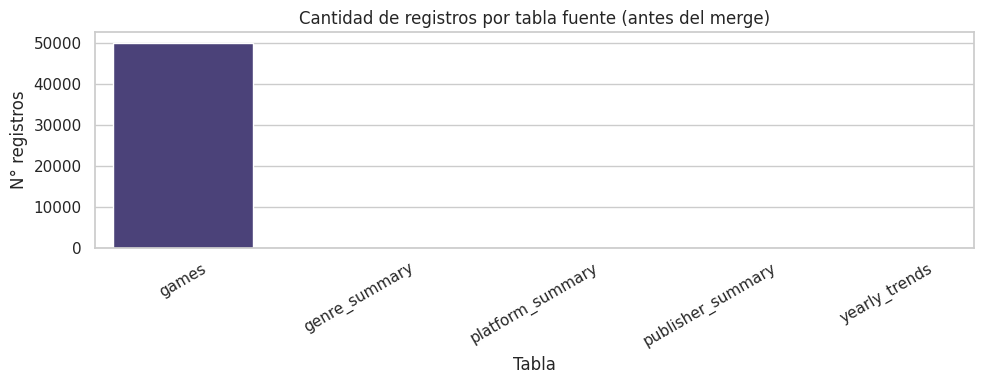

In [6]:
# Visualización 1: cobertura de datos por tabla origen
print("Dimensiones de cada tabla cargada:")
for table_name, df_table in raw_tables.items():
    print(f"  {table_name:20} → {df_table.shape}")

plt.figure(figsize=(10, 4))
table_names = list(raw_tables.keys())
row_counts = [raw_tables[t].shape[0] for t in table_names]
sns.barplot(x=table_names, y=row_counts, palette="viridis")
plt.title("Cantidad de registros por tabla fuente (antes del merge)")
plt.xlabel("Tabla")
plt.ylabel("N° registros")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

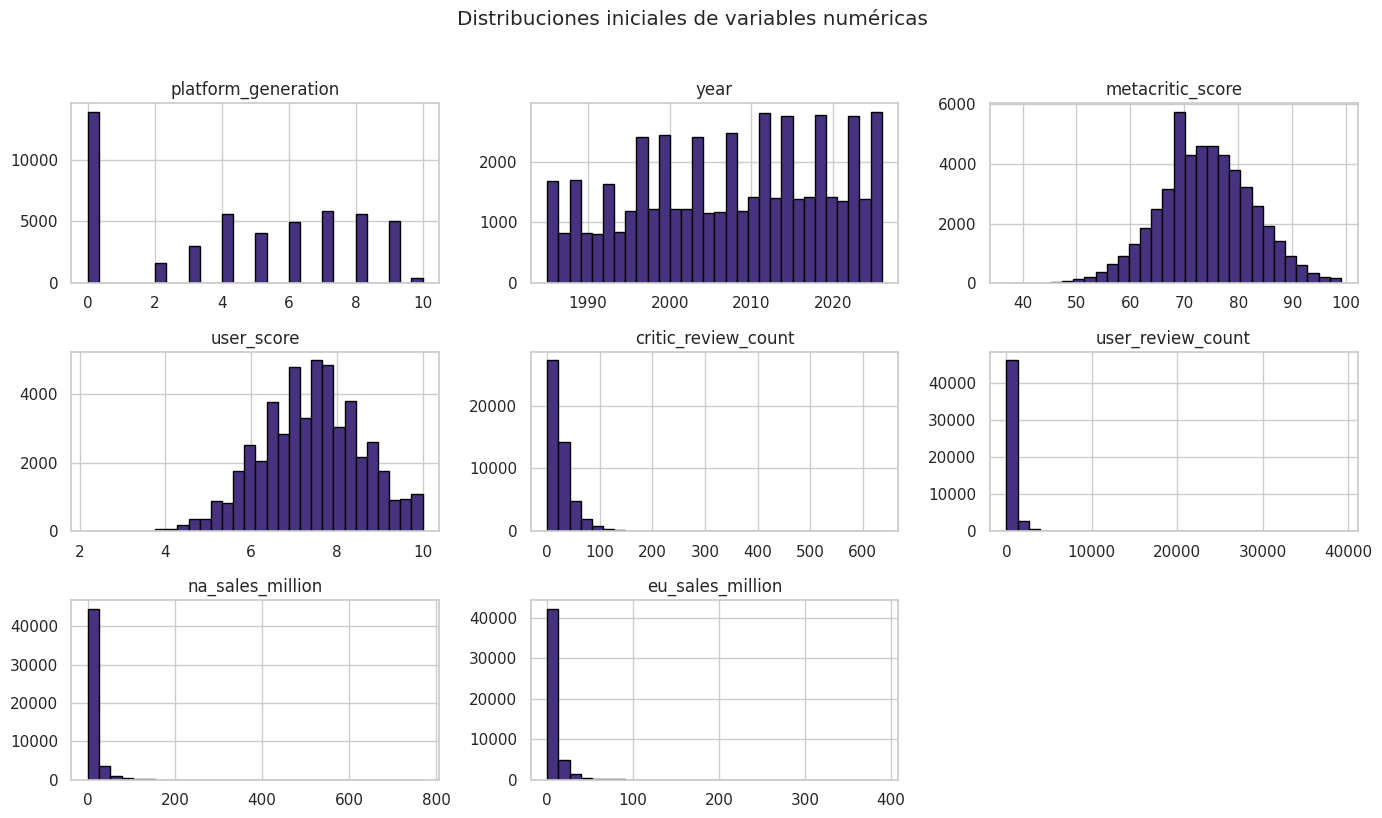

In [7]:
# Visualización 2: distribución de variables numéricas (primeras 8)
numeric_cols = df_all.select_dtypes(include="number").columns.tolist()
plot_cols = numeric_cols[:8]

if len(plot_cols) > 0:
    df_all[plot_cols].hist(figsize=(14, 8), bins=30, edgecolor="black")
    plt.suptitle("Distribuciones iniciales de variables numéricas", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron columnas numéricas para histogramas.")

Total columnas numéricas: 55
Primeras numéricas: ['platform_generation', 'year', 'metacritic_score', 'user_score', 'critic_review_count', 'user_review_count', 'na_sales_million', 'eu_sales_million', 'jp_sales_million', 'other_sales_million', 'global_sales_million', 'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel', 'online_multiplayer']


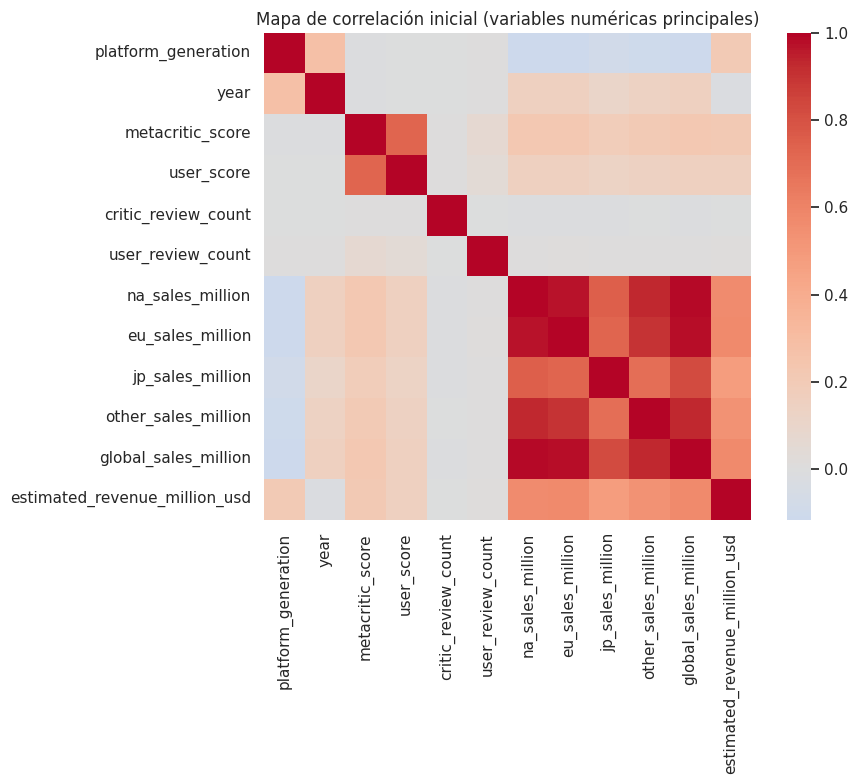

In [8]:
# Visualización 3: matriz de correlación de variables numéricas principales (subset)
numeric_cols = df_all.select_dtypes(include="number").columns.tolist()
print(f"Total columnas numéricas: {len(numeric_cols)}")
print(f"Primeras numéricas: {numeric_cols[:15]}")

# Seleccionar subset para visualizar
corr_cols = numeric_cols[:12]  # Primeras 12 columnas numéricas

if len(corr_cols) >= 2:
    corr_matrix = df_all[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
    plt.title("Mapa de correlación inicial (variables numéricas principales)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes columnas numéricas válidas para correlación.")

In [9]:
# (Opcional) Guardar dataset unificado para usarlo en otros notebooks/scripts
output_path = Path("/home/diegono/VII/D.S./FIN/dataset_unificado.csv")
# df_all.to_csv(output_path, index=False)
print(f"Cuando quieras exportarlo, descomenta la línea to_csv. Ruta objetivo: {output_path}")

Cuando quieras exportarlo, descomenta la línea to_csv. Ruta objetivo: /home/diegono/VII/D.S./FIN/dataset_unificado.csv


## Próximo paso recomendado (CRISP-DM)
Define el problema analítico (clasificación, regresión o clustering), selecciona variable objetivo (si aplica), y decide qué subset de `df_all` usarás para modelado.